In [1]:
import pandas as pd
# Load your merged dataset
df = pd.read_csv('../output/fifa_merged.csv')

# Quick look
df.head()

C:\Users\aarya\AppData\Local\Temp\ipykernel_28988\1326198992.py:3: DtypeWarning: Columns (64) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../output/fifa_merged.csv')


,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Best Position,Best Overall Rating,Year,Release Clause,DefensiveAwareness
0,176580,L. Suárez,29,https://cdn.sofifa.com/players/176/580/17_60.png,Uruguay,https://cdn.sofifa.com/flags/uy.png,92,92,FC Barcelona,https://cdn.sofifa.com/teams/241/light_30.png,...,27.0,25.0,31.0,33.0,37.0,ST,88.0,2017,NaN,NaN
1,178518,R. Nainggolan,28,https://cdn.sofifa.com/players/178/518/17_60.png,Belgium,https://cdn.sofifa.com/flags/be.png,86,86,Roma,https://cdn.sofifa.com/teams/52/light_30.png,...,11.0,11.0,14.0,8.0,11.0,CDM,84.0,2017,NaN,NaN
2,181872,A. Vidal,29,https://cdn.sofifa.com/players/181/872/17_60.png,Chile,https://cdn.sofifa.com/flags/cl.png,87,87,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,4.0,2.0,4.0,2.0,4.0,CDM,85.0,2017,NaN,NaN
3,197445,D. Alaba,24,https://cdn.sofifa.com/players/197/445/17_60.png,Austria,https://cdn.sofifa.com/flags/at.png,86,89,FC Bayern München,https://cdn.sofifa.com/teams/21/light_30.png,...,5.0,7.0,14.0,15.0,9.0,LB,84.0,2017,NaN,NaN
4,195864,P. Pogba,23,https://cdn.sofifa.com/players/195/864/17_60.png,France,https://cdn.sofifa.com/flags/fr.png,88,94,Manchester United,https://cdn.sofifa.com/teams/11/light_30.png,...,5.0,6.0,2.0,4.0,3.0,CAM,85.0,2017,NaN,NaN


In [2]:
# Shape of dataset
print(f"Dataset shape: {df.shape}")

Dataset shape: (104352, 66)


In [3]:
# Columns
df.columns.tolist()

['ID',
 'Name',
 'Age',
 'Photo',
 'Nationality',
 'Flag',
 'Overall',
 'Potential',
 'Club',
 'Club Logo',
 'Value',
 'Wage',
 'Special',
 'Preferred Foot',
 'International Reputation',
 'Weak Foot',
 'Skill Moves',
 'Work Rate',
 'Body Type',
 'Real Face',
 'Position',
 'Jersey Number',
 'Joined',
 'Loaned From',
 'Contract Valid Until',
 'Height',
 'Weight',
 'Crossing',
 'Finishing',
 'HeadingAccuracy',
 'ShortPassing',
 'Volleys',
 'Dribbling',
 'Curve',
 'FKAccuracy',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Reactions',
 'Balance',
 'ShotPower',
 'Jumping',
 'Stamina',
 'Strength',
 'LongShots',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'Marking',
 'StandingTackle',
 'SlidingTackle',
 'GKDiving',
 'GKHandling',
 'GKKicking',
 'GKPositioning',
 'GKReflexes',
 'Best Position',
 'Best Overall Rating',
 'Year',
 'Release Clause',
 'DefensiveAwareness']

In [4]:
# Show only columns where missing values > 0
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Loaned From             96509
DefensiveAwareness      56950
Marking                 47402
Release Clause          26844
Joined                  10461
Contract Valid Until     2536
Club                     1710
Composure                 958
Jersey Number             117
Position                  117
Balance                   115
Jumping                   115
Volleys                   115
Vision                    115
SlidingTackle             115
Agility                   115
Curve                     115
Body Type                  81
Real Face                  81
Interceptions              15
Positioning                15
dtype: int64

In [5]:
# What types of data are there?
df.dtypes.value_counts()

float64    40
object     20
int64       6
Name: count, dtype: int64

In [6]:
columns_to_drop = [
    'ID', 'Photo', 'Flag', 'Club Logo', 'Loaned From', 'DefensiveAwareness',
    'Marking', 'Release Clause', 'Joined', 'Contract Valid Until',
    'Jersey Number', 'Body Type', 'Real Face', 'Special', 'Best Position', 'Best Overall Rating'
]

In [7]:
# Drop columns
df_cleaned = df.drop(columns=columns_to_drop)

# Drop rows where important columns are missing
important_columns_for_rows = [
    'Club', 'Composure', 'Position', 'Balance', 'Jumping', 'Volleys',
    'Vision', 'SlidingTackle', 'Agility', 'Curve', 'Interceptions', 'Positioning'
]

df_cleaned = df_cleaned.dropna(subset=important_columns_for_rows)

print(f"Shape after full cleaning: {df_cleaned.shape}")
df_cleaned.head()


Shape after full cleaning: (101760, 50)


,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,...,Penalties,Composure,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year
0,L. Suárez,29,Uruguay,92,92,FC Barcelona,€83M,€525K,Right,5.0,...,85.0,83.0,45.0,38.0,27.0,25.0,31.0,33.0,37.0,2017
1,R. Nainggolan,28,Belgium,86,86,Roma,€37.5M,€130K,Right,3.0,...,63.0,85.0,85.0,88.0,11.0,11.0,14.0,8.0,11.0,2017
2,A. Vidal,29,Chile,87,87,FC Bayern München,€41.5M,€180K,Right,4.0,...,84.0,86.0,89.0,84.0,4.0,2.0,4.0,2.0,4.0,2017
3,D. Alaba,24,Austria,86,89,FC Bayern München,€41.5M,€140K,Left,4.0,...,80.0,79.0,83.0,83.0,5.0,7.0,14.0,15.0,9.0,2017
4,P. Pogba,23,France,88,94,Manchester United,€71.5M,€225K,Right,4.0,...,76.0,83.0,73.0,73.0,5.0,6.0,2.0,4.0,3.0,2017


In [8]:
import re

def clean_position(pos):
    if pd.isnull(pos):
        return None
    # Extract just the position letters (remove HTML tags)
    match = re.search(r'>([A-Z]+)', pos)
    if match:
        return match.group(1)
    else:
        return pos.strip()  # fallback

# Apply cleaning
df_cleaned['Position'] = df_cleaned['Position'].apply(clean_position)

# Quick check
df_cleaned['Position'].value_counts()

Position
SUB    43588
RES    17956
RCB     3586
LCB     3582
GK      3478
RB      2976
LB      2967
ST      2610
RM      2401
LM      2354
LCM     2230
RCM     2225
CAM     1781
RDM     1357
LDM     1356
LS      1215
RS      1213
CDM      869
LW       862
RW       842
CB       625
CM       398
RWB      378
LWB      377
RAM      139
LAM      132
LF        99
RF        98
CF        66
Name: count, dtype: int64

In [9]:
def height_to_inches(height):
    if pd.isnull(height):
        return None
    height = height.strip()
    
    # Case 1: Height is in cm
    if 'cm' in height:
        cm_val = float(height.replace('cm', '').strip())
        return cm_val * 0.393701  # 1 cm = 0.393701 inches
    
    # Case 2: Height is in feet'inches (like 5'9)
    elif "'" in height:
        parts = height.split("'")
        if len(parts) == 2:
            try:
                feet = int(parts[0])
                inches = int(parts[1])
                return feet * 12 + inches
            except ValueError:
                return None  # in case it's broken
    else:
        return None  # fallback if unexpected format

# Apply again to your data
df_cleaned['Height_in_inches'] = df_cleaned['Height'].apply(height_to_inches)


In [10]:
def clean_weight(w):
    if pd.isnull(w):
        return None
    w = w.strip()
    if 'lbs' in w:
        return int(w.replace('lbs', '').strip())
    elif 'kg' in w:
        kg_val = float(w.replace('kg', '').strip())
        return int(kg_val * 2.20462)  # Convert kg to lbs
    else:
        return None  # fallback if unexpected format

# Apply it again
df_cleaned['Weight_lbs'] = df_cleaned['Weight'].apply(clean_weight)

# Optional: drop the old 'Weight' column now if you want
df_cleaned = df_cleaned.drop(columns=['Weight'])


In [11]:
df_cleaned.head()

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
0,L. Suárez,29,Uruguay,92,92,FC Barcelona,€83M,€525K,Right,5.0,...,45.0,38.0,27.0,25.0,31.0,33.0,37.0,2017,72.0,190
1,R. Nainggolan,28,Belgium,86,86,Roma,€37.5M,€130K,Right,3.0,...,85.0,88.0,11.0,11.0,14.0,8.0,11.0,2017,69.0,143
2,A. Vidal,29,Chile,87,87,FC Bayern München,€41.5M,€180K,Right,4.0,...,89.0,84.0,4.0,2.0,4.0,2.0,4.0,2017,71.0,165
3,D. Alaba,24,Austria,86,89,FC Bayern München,€41.5M,€140K,Left,4.0,...,83.0,83.0,5.0,7.0,14.0,15.0,9.0,2017,71.0,168
4,P. Pogba,23,France,88,94,Manchester United,€71.5M,€225K,Right,4.0,...,73.0,73.0,5.0,6.0,2.0,4.0,3.0,2017,75.0,185


In [12]:
# Remove rows where Position is 'SUB' or 'RES'
df_cleaned = df_cleaned[~df_cleaned['Position'].isin(['SUB', 'RES'])]

print(f"Shape after removing SUB/RES players: {df_cleaned.shape}")

Shape after removing SUB/RES players: (40216, 51)


In [13]:
df_cleaned.describe()

,Age,Overall,Potential,International Reputation,Weak Foot,Skill Moves,Crossing,Finishing,HeadingAccuracy,ShortPassing,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
count,40216.000000,40216.00000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,...,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000,40216.000000
mean,26.209966,69.67222,72.930625,1.183683,3.021036,2.474960,53.941416,48.763577,55.850408,62.762184,...,52.164139,49.630296,15.774219,15.588025,15.452357,15.655983,15.888900,2019.451686,71.411202,166.901358
std,4.274409,6.03990,6.059403,0.508149,0.685078,0.782991,17.992576,19.513976,16.886392,13.481300,...,21.415626,21.297419,17.332773,16.541880,16.078835,16.931540,17.702683,1.712989,2.667134,15.538378
min,16.000000,47.00000,49.000000,1.000000,1.000000,1.000000,6.000000,3.000000,4.000000,7.000000,...,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2017.000000,61.000000,110.000000
25%,23.000000,66.00000,69.000000,1.000000,3.000000,2.000000,44.000000,33.000000,49.000000,59.000000,...,33.000000,29.000000,8.000000,8.000000,8.000000,8.000000,8.000000,2018.000000,69.685077,156.000000
50%,26.000000,69.00000,73.000000,1.000000,3.000000,2.000000,59.000000,52.000000,59.000000,65.000000,...,61.000000,58.000000,11.000000,11.000000,11.000000,11.000000,11.000000,2019.000000,71.259881,165.000000
75%,29.000000,73.00000,77.000000,1.000000,3.000000,3.000000,67.000000,65.000000,68.000000,71.000000,...,69.000000,67.000000,14.000000,14.000000,14.000000,14.000000,14.000000,2021.000000,73.000000,176.000000
max,44.000000,94.00000,95.000000,5.000000,5.000000,5.000000,94.000000,95.000000,94.000000,94.000000,...,93.000000,95.000000,91.000000,92.000000,93.000000,92.000000,93.000000,2022.000000,81.000000,243.000000


In [14]:
df_cleaned.columns.tolist()

['Name',
 'Age',
 'Nationality',
 'Overall',
 'Potential',
 'Club',
 'Value',
 'Wage',
 'Preferred Foot',
 'International Reputation',
 'Weak Foot',
 'Skill Moves',
 'Work Rate',
 'Position',
 'Height',
 'Crossing',
 'Finishing',
 'HeadingAccuracy',
 'ShortPassing',
 'Volleys',
 'Dribbling',
 'Curve',
 'FKAccuracy',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Reactions',
 'Balance',
 'ShotPower',
 'Jumping',
 'Stamina',
 'Strength',
 'LongShots',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'StandingTackle',
 'SlidingTackle',
 'GKDiving',
 'GKHandling',
 'GKKicking',
 'GKPositioning',
 'GKReflexes',
 'Year',
 'Height_in_inches',
 'Weight_lbs']

In [15]:
# Removed Wage and Value because of scaling
important_numeric_attributes = [
    'Overall', 'Potential', 'Age',
    'Height_in_inches', 'Weight_lbs',
    'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
    'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
    'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
    'ShotPower', 'LongShots', 'Aggression', 'Interceptions',
    'Positioning', 'Vision', 'Penalties', 'Composure',
    'StandingTackle', 'SlidingTackle',
    'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes'
]

In [16]:
important_categorical_attributes = [
    'Position', 'Nationality', 'Club', 'Preferred Foot', 'Work Rate', 'Skill Moves', 'Weak Foot', 'International Reputation'
]

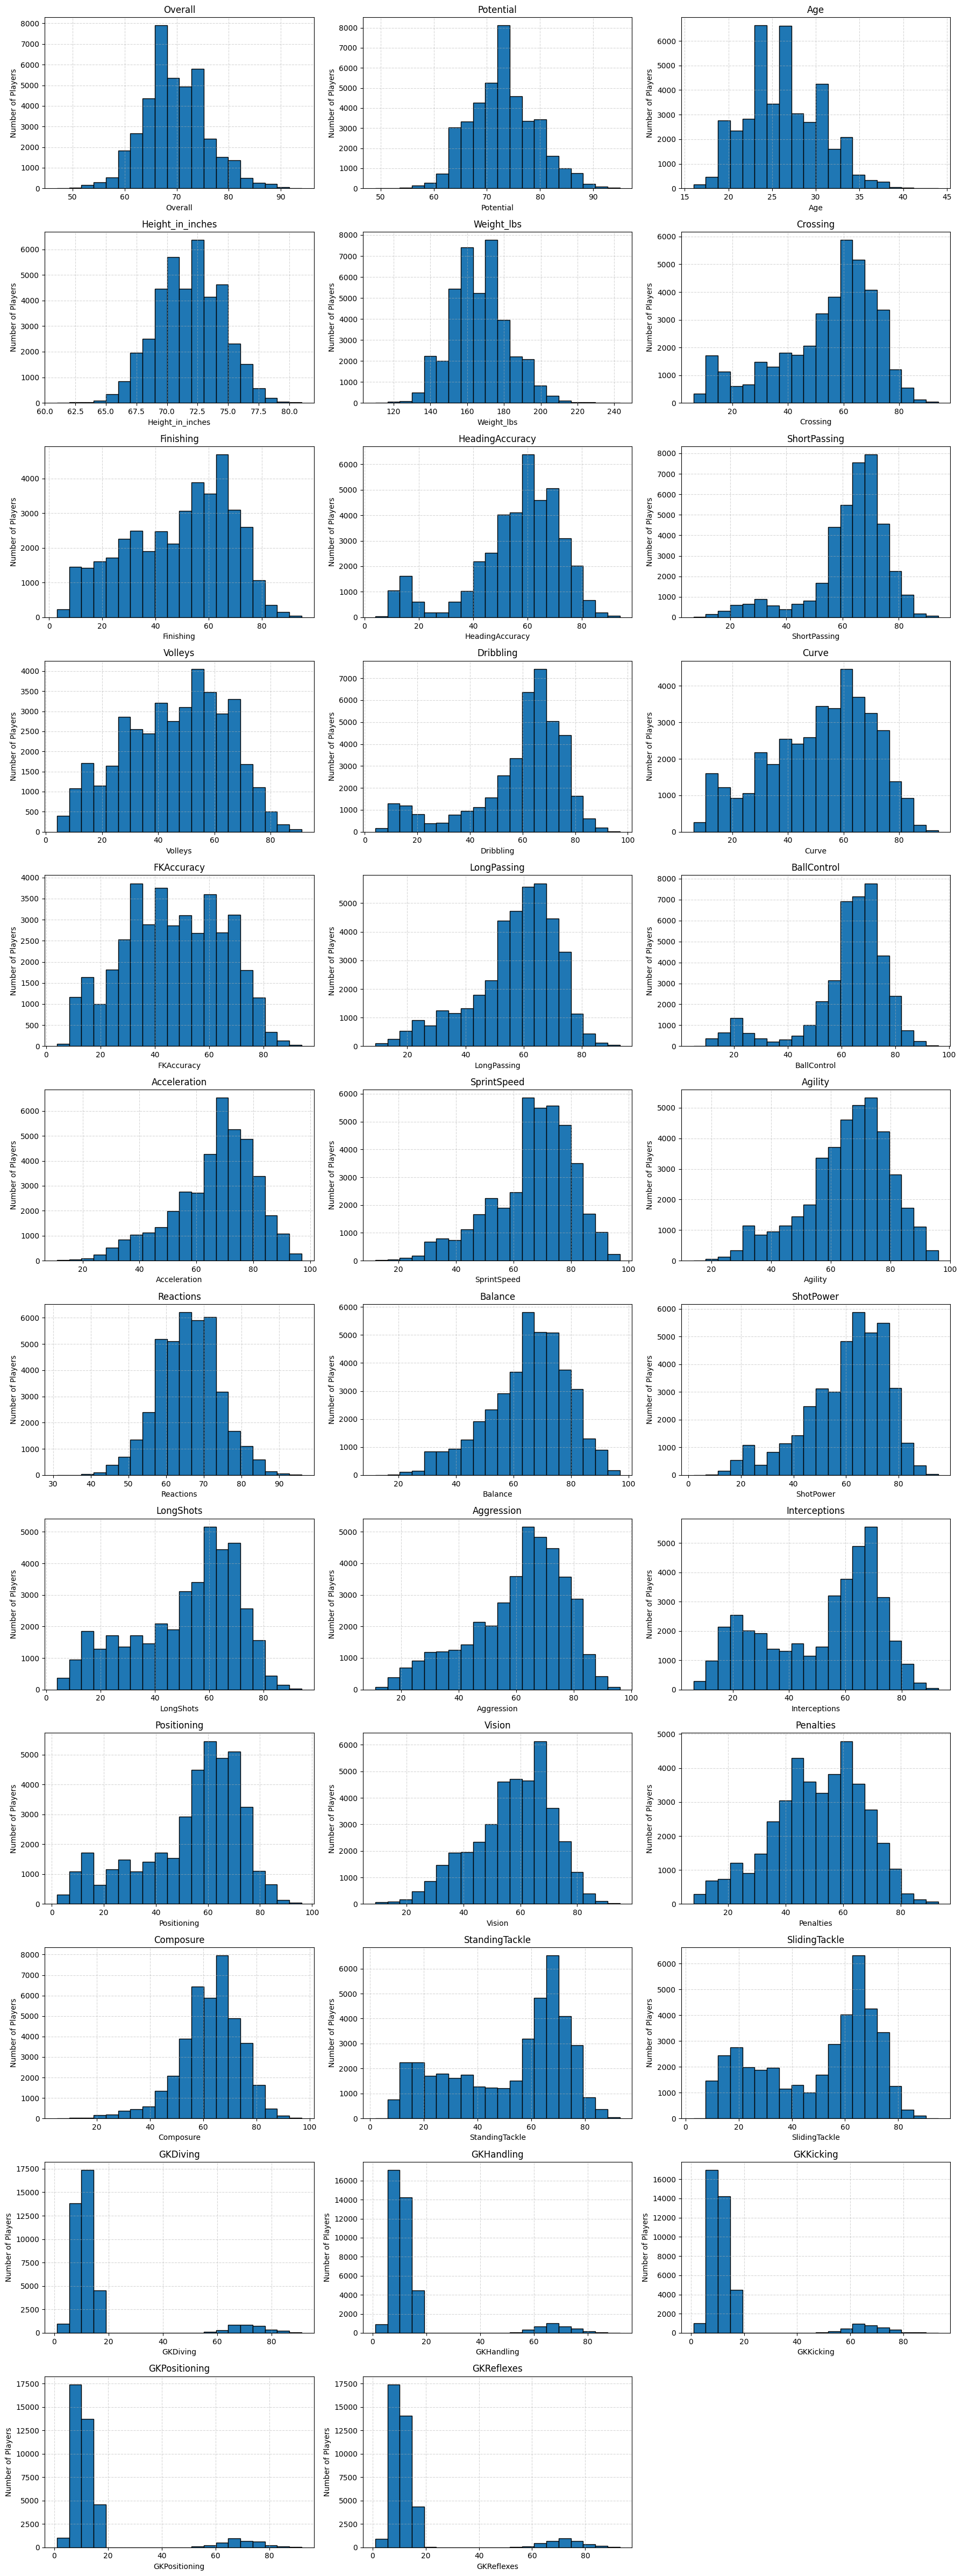

In [17]:
import math
import matplotlib.pyplot as plt

# How many columns per row
cols = 3
# Calculate how many rows we need
rows = math.ceil(len(important_numeric_attributes) / cols)

# Create the subplots grid
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()  # Flatten axes for easy indexing

# Loop through all attributes
for idx, attribute in enumerate(important_numeric_attributes):
    axes[idx].hist(df_cleaned[attribute].dropna(), bins=20, edgecolor='black')
    axes[idx].set_title(attribute)
    axes[idx].set_xlabel(attribute)
    axes[idx].set_ylabel('Number of Players')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

# Hide any unused subplots (in case grid is bigger than needed)
for idx in range(len(important_numeric_attributes), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

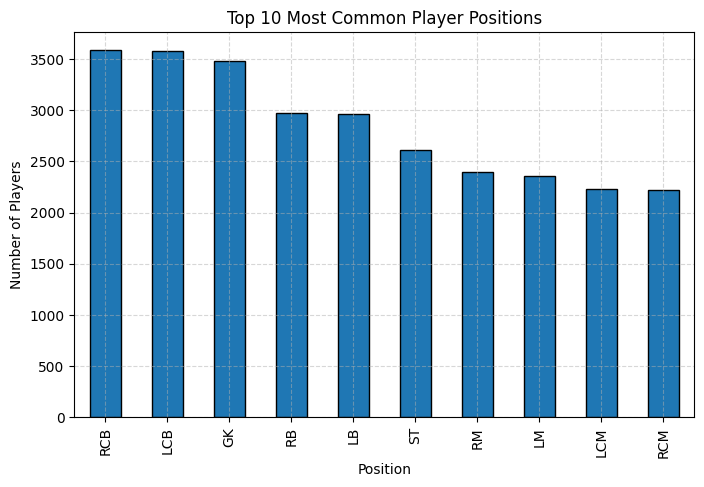

In [18]:
df_cleaned['Position'].value_counts().head(10).plot(kind='bar', figsize=(8,5), edgecolor='black')
plt.title('Top 10 Most Common Player Positions')
plt.xlabel('Position')
plt.ylabel('Number of Players')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

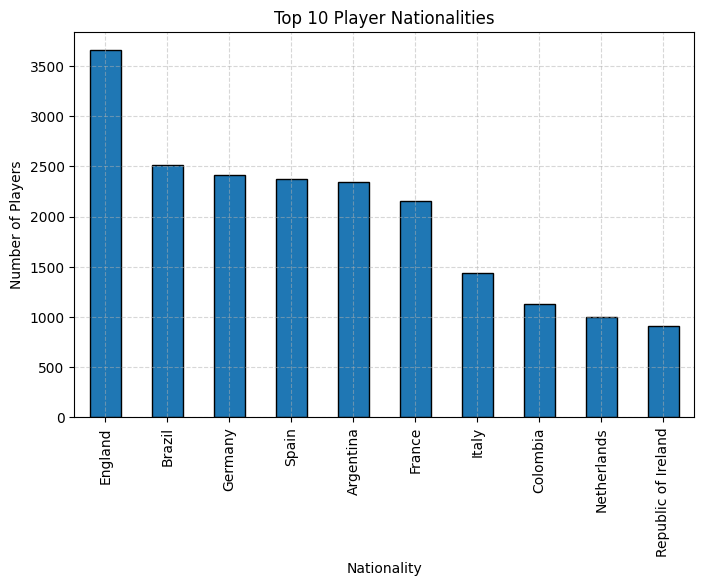

In [19]:
df_cleaned['Nationality'].value_counts().head(10).plot(kind='bar', figsize=(8,5), edgecolor='black')
plt.title('Top 10 Player Nationalities')
plt.xlabel('Nationality')
plt.ylabel('Number of Players')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


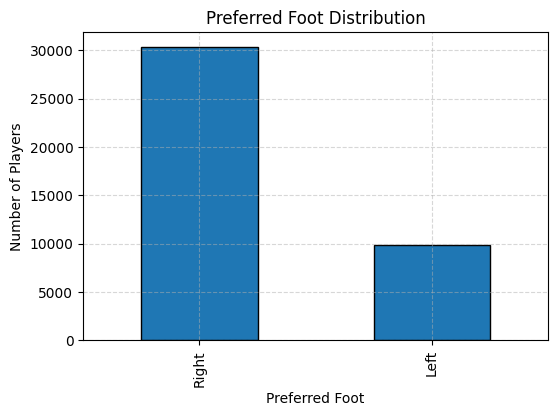

In [20]:
df_cleaned['Preferred Foot'].value_counts().plot(kind='bar', figsize=(6,4), edgecolor='black')
plt.title('Preferred Foot Distribution')
plt.xlabel('Preferred Foot')
plt.ylabel('Number of Players')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [21]:
# Select only numeric columns
numeric_df = df_cleaned.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

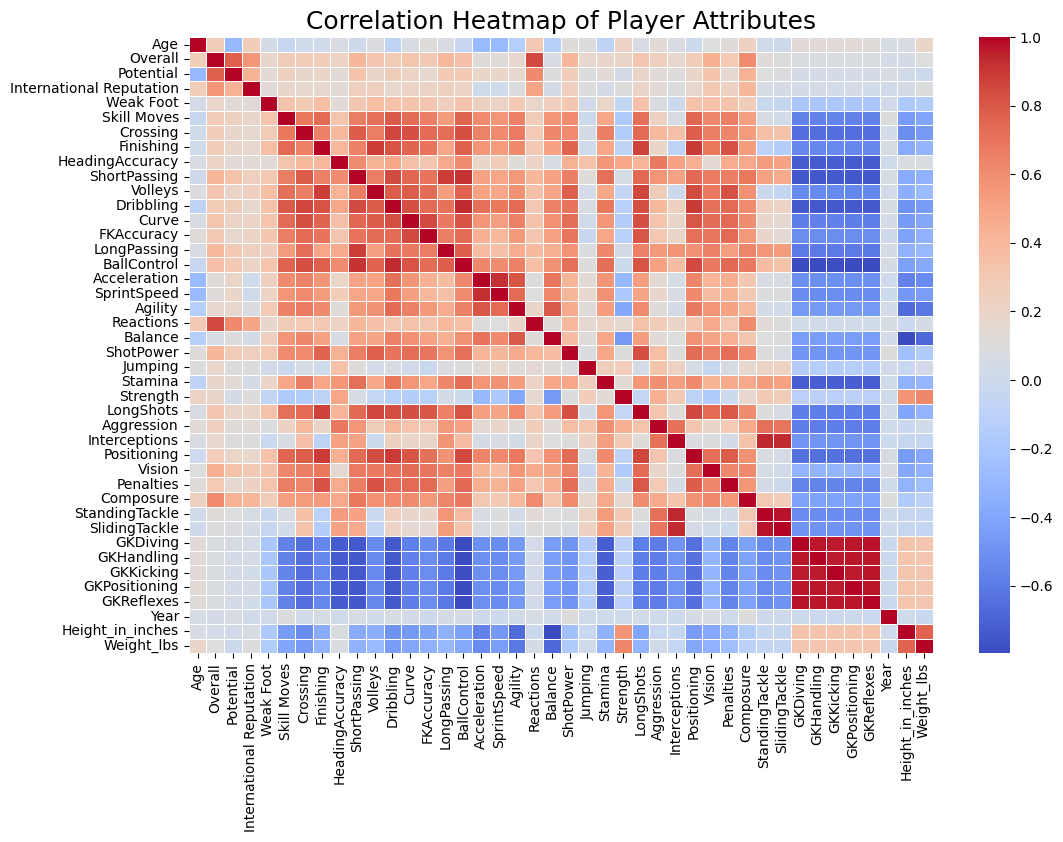

In [22]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Player Attributes', fontsize=18)
plt.show()

# Key Observations from Correlation Heatmap

## Attribute Relationships:

- **Overall Rating** correlates strongly with:
  - **Reactions**
  - **Composure**
  - **ShortPassing**
  - **BallControl**
  - **Vision**

- **Playmaking attributes** like Dribbling, BallControl, Vision, and ShortPassing are highly correlated among each other.

- **Physical attributes** (Jumping, Strength, Stamina) form a separate group but have **weaker correlation with Overall Rating**.

- **Goalkeeper attributes** (GKHandling, GKDiving, GKPositioning, etc.) are highly correlated with each other, but **separate from field player attributes**.

- **Height and Weight** show **very low correlation** with Overall Rating.
  - Meaning: Being tall or heavy doesn’t necessarily make a player higher-rated.

- **Age** is **mildly negatively correlated** with Potential.
  - Younger players tend to have higher potential.

## Strategic Insights:

- Technical and mental skills (BallControl, Vision, Reactions, Composure) are **strong indicators of a player's Overall Rating**.
- Physical strength matters in gameplay but **less so for rating evaluations**.
- Goalkeepers should be analyzed separately from field players for more meaningful insights.



In [23]:
# Correlations with Overall
overall_corr = correlation_matrix['Overall'].drop('Overall')  # drop self-correlation

# Sort by absolute value (strongest correlations)
overall_corr_sorted = overall_corr.abs().sort_values(ascending=False)
print(overall_corr_sorted.head(10))


Reactions                   0.848884
Potential                   0.771873
Composure                   0.613258
International Reputation    0.569790
Vision                      0.446943
ShotPower                   0.405193
ShortPassing                0.404472
LongPassing                 0.391072
BallControl                 0.348611
Curve                       0.322047
Name: Overall, dtype: float64


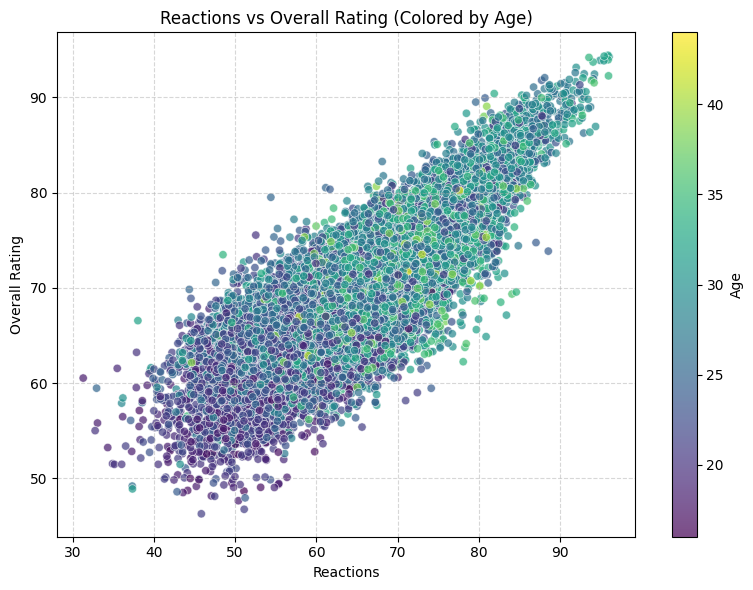

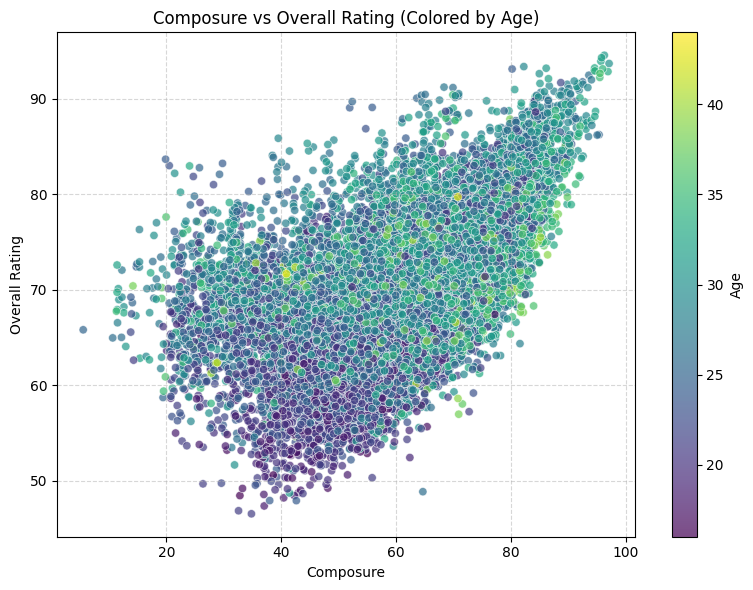

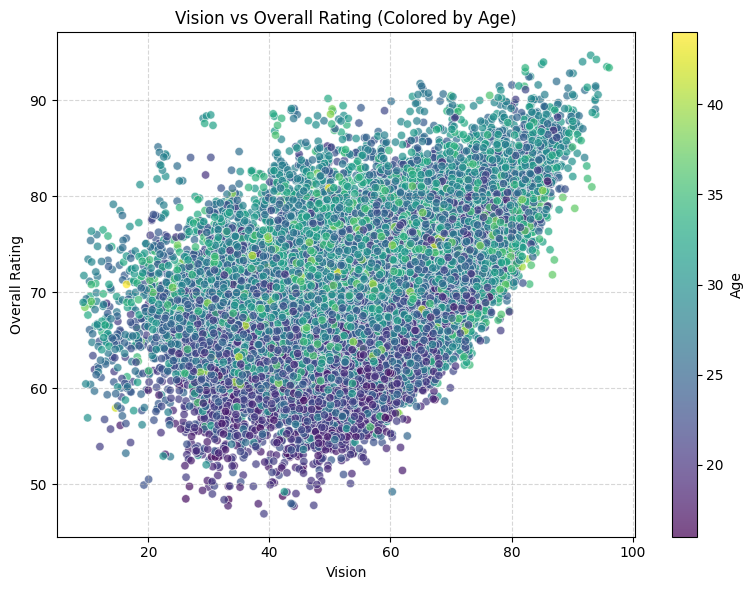

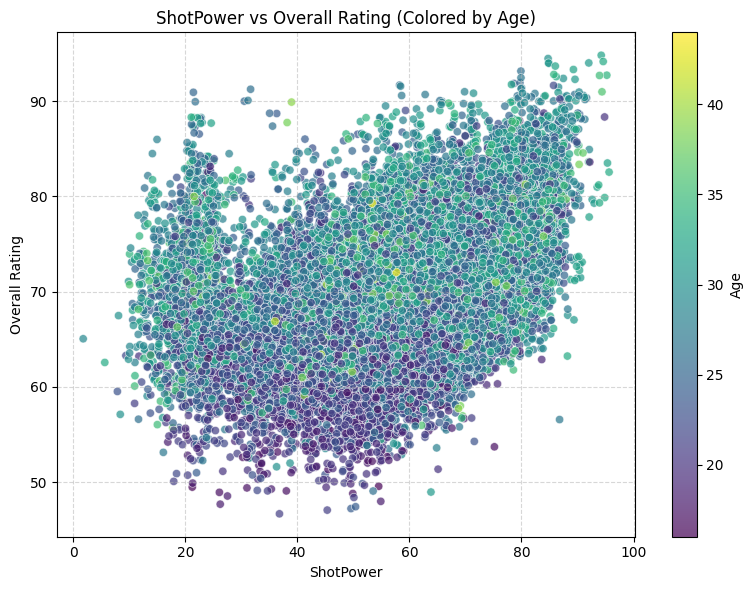

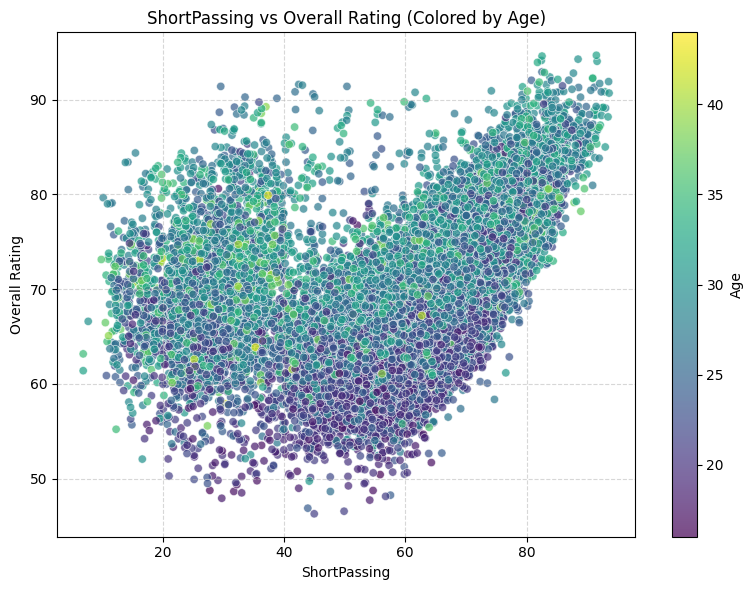

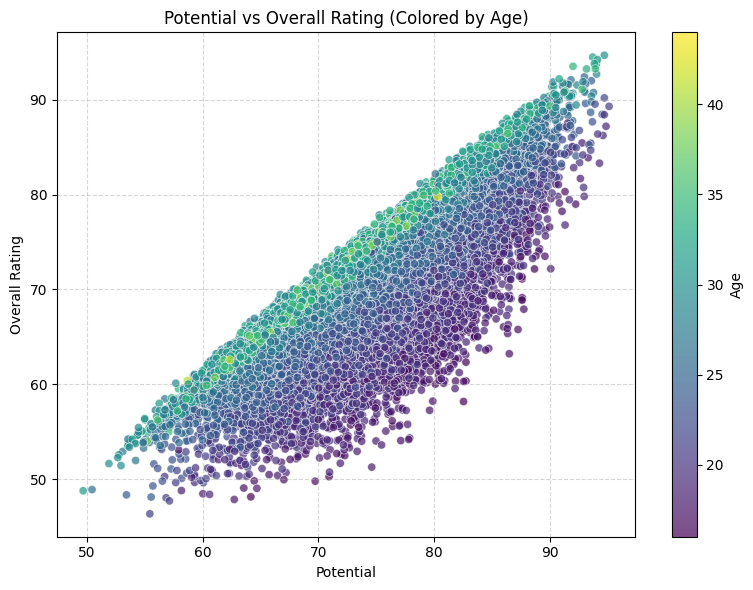

In [24]:
import numpy as np

# Focused attributes
focused_attributes = ['Reactions', 'Composure', 'Vision', 'ShotPower', 'ShortPassing', 'Potential']

for attribute in focused_attributes:
    plt.figure(figsize=(8,6))
    
    # Add small random noise (jitter) to X and Y
    x_jitter = df_cleaned[attribute] + np.random.normal(0, 0.5, size=len(df_cleaned))
    y_jitter = df_cleaned['Overall'] + np.random.normal(0, 0.5, size=len(df_cleaned))
    
    scatter = plt.scatter(
        x=x_jitter,
        y=y_jitter,
        c=df_cleaned['Age'],          # Coloring by Age
        cmap='viridis',               # Nice continuous gradient
        alpha=0.7,
        edgecolors='w',
        linewidth=0.5
    )
    
    plt.colorbar(scatter, label='Age')
    plt.title(f'{attribute} vs Overall Rating (Colored by Age)')
    plt.xlabel(attribute)
    plt.ylabel('Overall Rating')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# Key Finding: Impact of Age on Overall Rating

Although young players (typically under 25 years old) often display strong individual attributes — particularly in areas such as Vision, ShotPower, and ShortPassing — they generally do not achieve the highest Overall Ratings.

This is evident from the scatterplots where players aged under 25 (represented by darker colors in the Viridis colormap) are distributed across a wide range of Overall Ratings, even when they possess high scores in key attributes.

This pattern suggests that:

- **Technical ability alone is not sufficient** for a high Overall Rating.
- **Experience, maturity, exposure to high-level competition, and consistency** likely play critical roles in a player’s development.
- **Older players (30+ years)**, even if they have comparable or slightly lower individual stats, tend to cluster more tightly at higher Overall Ratings.
- **Overall Rating appears to capture both technical skill and professional maturity**, not just raw attributes.

In summary, while young players show promise through strong attribute scores, the transition to elite Overall Ratings is influenced by factors beyond pure skill — notably, game sense, tactical awareness, and consistent high-level performance developed over time.


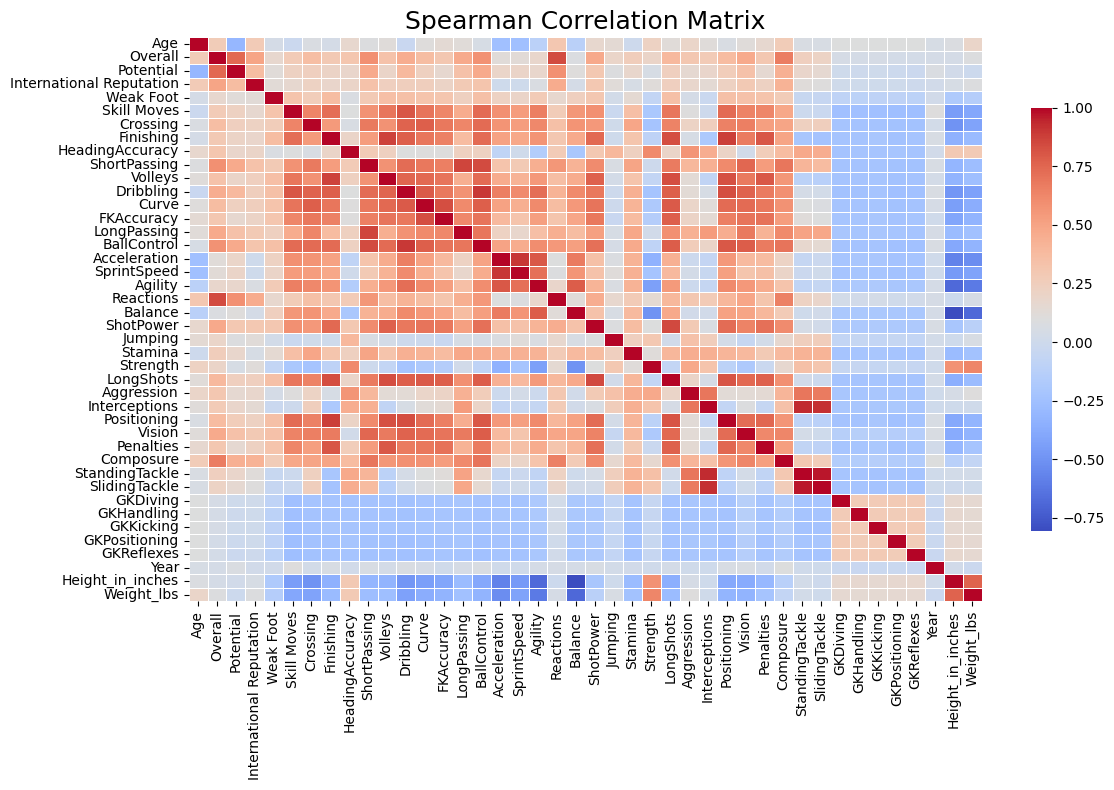

In [25]:
# Calculate Spearman correlation
spearman_corr = df_cleaned.select_dtypes(include=['int64', 'float64']).corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    spearman_corr,
    cmap='coolwarm',
    annot=False,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.75}
)
plt.title('Spearman Correlation Matrix', fontsize=18)
plt.tight_layout()
plt.show()

In [26]:
# First, flatten the correlation matrix
spearman_corr_flat = spearman_corr.unstack()

# Convert to a DataFrame for easy handling
spearman_corr_df = pd.DataFrame(spearman_corr_flat, columns=['Correlation']).reset_index()
spearman_corr_df.columns = ['Attribute 1', 'Attribute 2', 'Correlation']

# Drop self-correlations (where Attribute 1 == Attribute 2)
spearman_corr_df = spearman_corr_df[spearman_corr_df['Attribute 1'] != spearman_corr_df['Attribute 2']]

# Sort by absolute correlation value (highest first)
spearman_corr_df['AbsCorrelation'] = spearman_corr_df['Correlation'].abs()
spearman_corr_df = spearman_corr_df.sort_values(by='AbsCorrelation', ascending=False)

# Optional: Drop duplicate pairs (e.g., (A,B) and (B,A))
spearman_corr_df['Pairs'] = list(zip(spearman_corr_df['Attribute 1'], spearman_corr_df['Attribute 2']))
spearman_corr_df['SortedPairs'] = spearman_corr_df['Pairs'].apply(lambda x: tuple(sorted(x)))
spearman_corr_df = spearman_corr_df.drop_duplicates(subset='SortedPairs')

# Final sorted, clean table
top_correlations = spearman_corr_df[['Attribute 1', 'Attribute 2', 'Correlation']]

# View top 20 correlated pairs
top_correlations.head(40)


,Attribute 1,Attribute 2,Correlation
1377,StandingTackle,SlidingTackle,0.965684
1166,Interceptions,StandingTackle,0.934048
1413,SlidingTackle,Interceptions,0.918223
730,SprintSpeed,Acceleration,0.908203
641,BallControl,Dribbling,0.897492
322,Finishing,Positioning,0.886010
427,Volleys,Finishing,0.867894
392,ShortPassing,LongPassing,0.861447
907,ShotPower,LongShots,0.850249
639,BallControl,ShortPassing,0.841518


C:\Users\aarya\AppData\Local\Temp\ipykernel_28988\3651435747.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_50['Pair'] = top_50['Attribute 1'] + ' vs ' + top_50['Attribute 2']


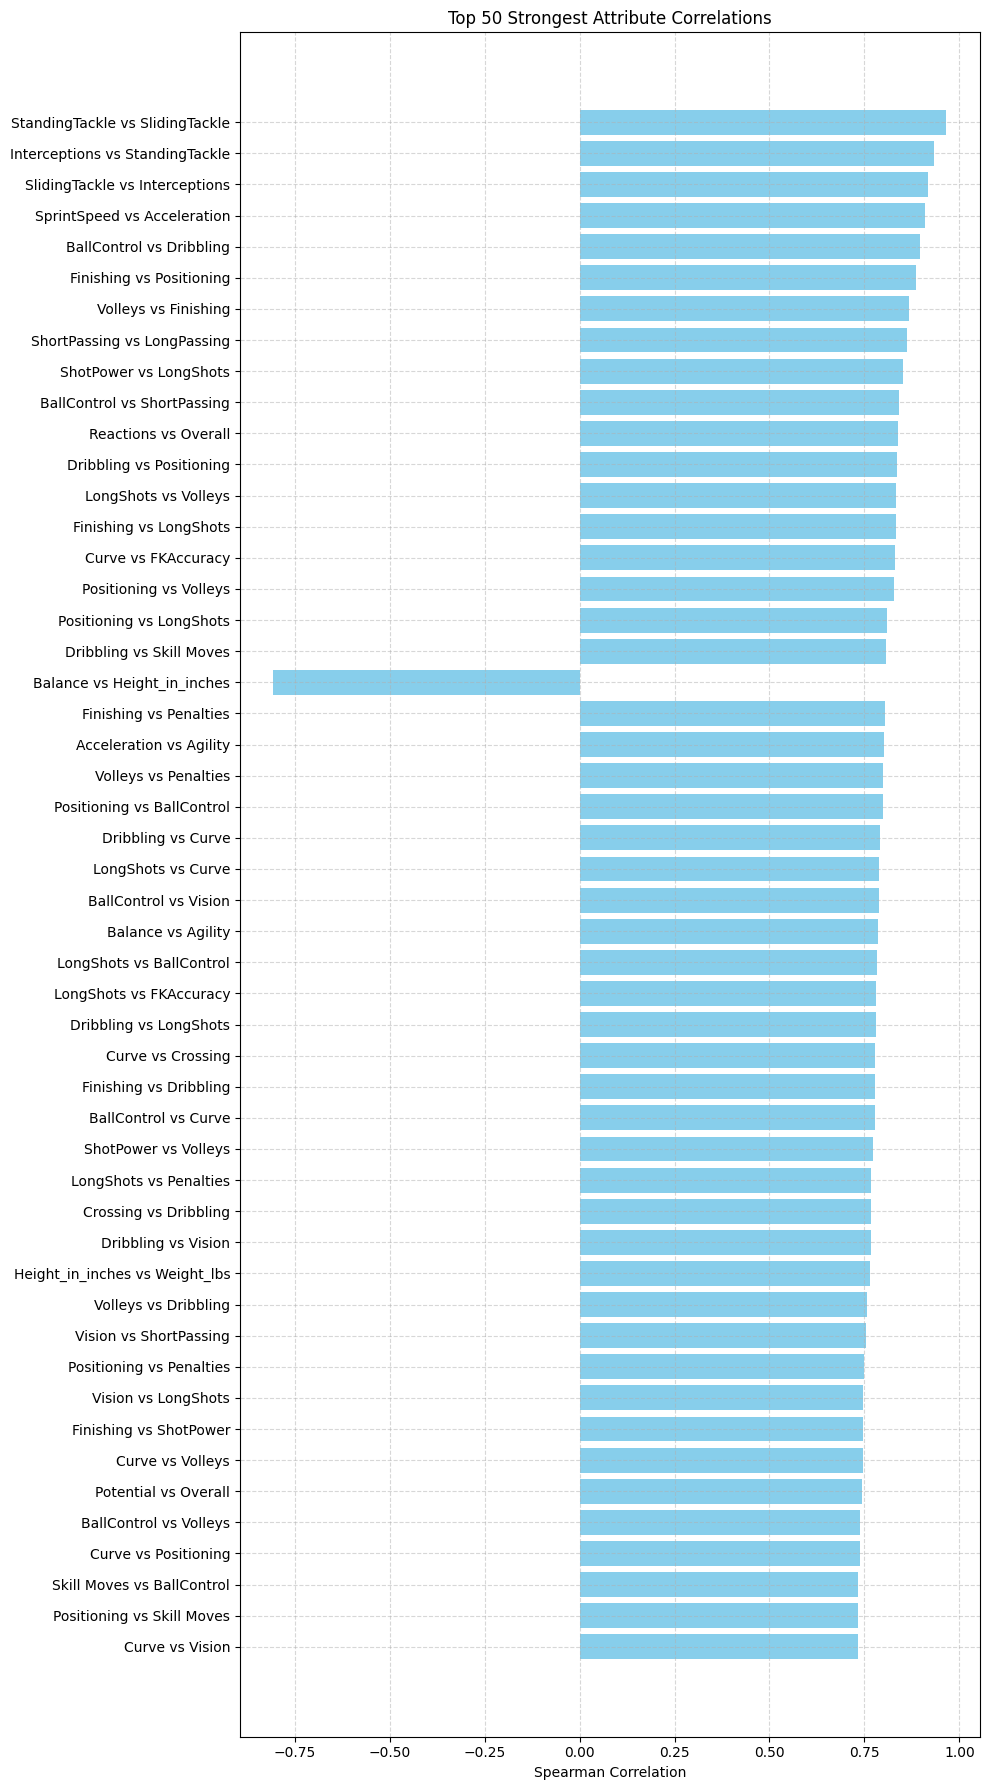

In [27]:
# Take the top 50 correlations
top_50 = top_correlations.head(50)

# Create a label for each pair
top_50['Pair'] = top_50['Attribute 1'] + ' vs ' + top_50['Attribute 2']

# Plot
plt.figure(figsize=(10, 18))
plt.barh(top_50['Pair'], top_50['Correlation'], color='skyblue')
plt.xlabel('Spearman Correlation')
plt.title('Top 50 Strongest Attribute Correlations')
plt.gca().invert_yaxis()  # Highest correlation at the top
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

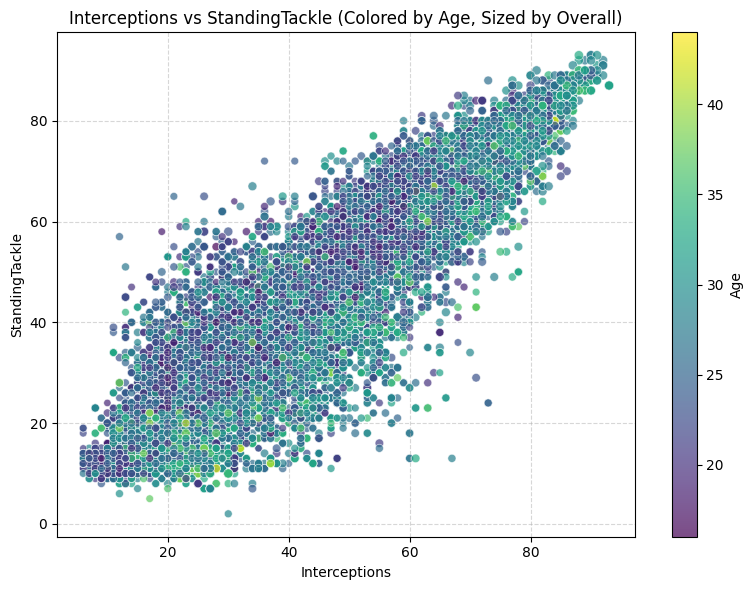

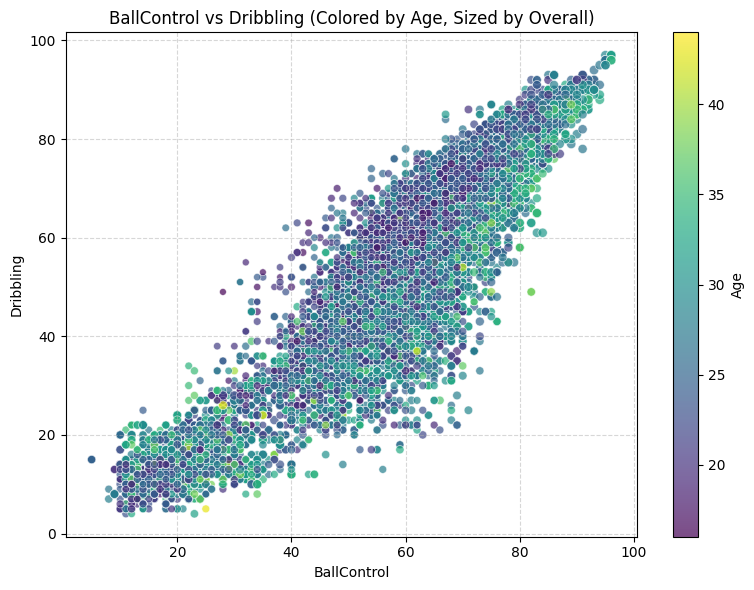

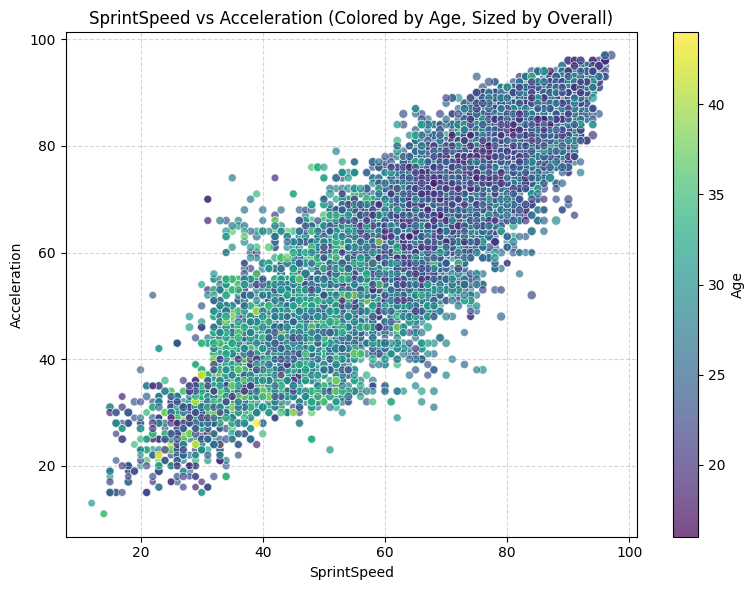

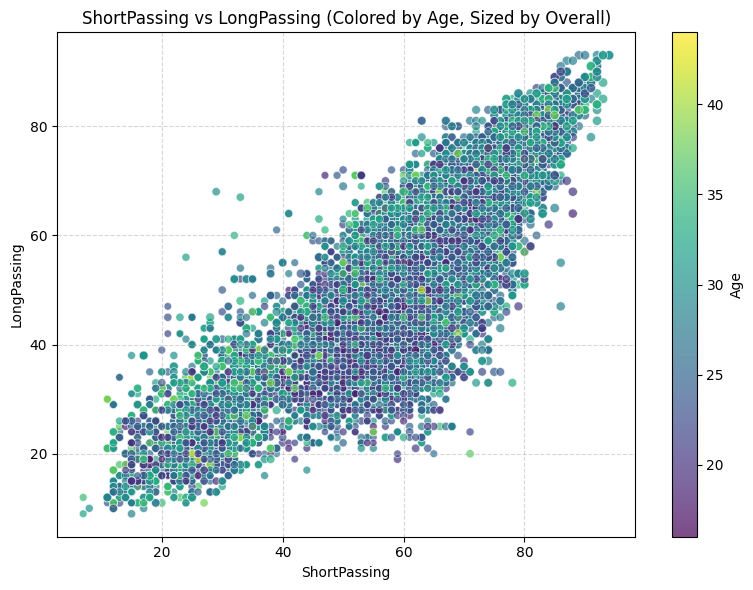

In [31]:
# List of logical pairs
pairs_to_plot = [
    ('Interceptions', 'StandingTackle'),
    ('BallControl', 'Dribbling'),
    ('SprintSpeed', 'Acceleration'),
    ('ShortPassing', 'LongPassing')
]

for x_attr, y_attr in pairs_to_plot:
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(
        x=df_cleaned[x_attr],
        y=df_cleaned[y_attr],
        c=df_cleaned['Age'],           # Color by Age
        s=df_cleaned['Overall'] / 2,   # Size by Overall (divided by 2 to keep dots reasonable)
        cmap='viridis',
        alpha=0.7,
        edgecolors='w',
        linewidth=0.5
    )
    plt.colorbar(scatter, label='Age')
    plt.title(f'{x_attr} vs {y_attr} (Colored by Age, Sized by Overall)')
    plt.xlabel(x_attr)
    plt.ylabel(y_attr)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [38]:
# Filter for latest year (FIFA 22)
latest_year = df_cleaned['Year'].max()
latest_df = df_cleaned[df_cleaned['Year'] == latest_year]

# Sort by Overall Rating and pick Top 10
top10_players_2022 = latest_df.sort_values(by='Overall', ascending=False).head(10)['Name'].tolist()

In [39]:
# Filter full dataframe for only these players
top10_career_data = df_cleaned[df_cleaned['Name'].isin(top10_players_2022)]

In [41]:
top10_career_data

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
87645,K. De Bruyne,30,Belgium,91,91,Manchester City,€125.5M,€350K,Right,4.0,...,65.0,53.0,15.0,13.0,5.0,10.0,13.0,2022,71.259881,154
87671,L. Messi,34,Argentina,93,93,Paris Saint-Germain,€78M,€320K,Left,5.0,...,35.0,24.0,6.0,11.0,15.0,14.0,8.0,2022,66.929170,158
87675,R. Lewandowski,32,Poland,92,92,FC Bayern München,€119.5M,€270K,Right,5.0,...,42.0,19.0,15.0,6.0,12.0,8.0,10.0,2022,72.834685,178
87678,Cristiano Ronaldo,36,Portugal,91,91,Manchester United,€45M,€270K,Right,5.0,...,32.0,24.0,7.0,11.0,15.0,14.0,11.0,2022,73.622087,182
87681,H. Kane,27,England,90,90,Tottenham Hotspur,€129.5M,€240K,Right,4.0,...,36.0,38.0,8.0,10.0,11.0,14.0,11.0,2022,74.015788,196
87706,Neymar Jr,29,Brazil,91,91,Paris Saint-Germain,€129M,€270K,Right,5.0,...,32.0,29.0,9.0,9.0,15.0,15.0,11.0,2022,68.897675,149
87713,N. Kanté,30,France,90,90,Chelsea,€100M,€230K,Right,4.0,...,93.0,86.0,15.0,12.0,10.0,7.0,10.0,2022,66.141768,154
87724,K. Mbappé,22,France,91,95,Paris Saint-Germain,€194M,€230K,Right,4.0,...,34.0,32.0,13.0,5.0,7.0,11.0,6.0,2022,71.653582,160
101532,M. ter Stegen,29,Germany,90,92,FC Barcelona,€99M,€250K,Right,4.0,...,13.0,10.0,88.0,85.0,88.0,88.0,90.0,2022,73.622087,187
101886,J. Oblak,28,Slovenia,91,93,Atlético de Madrid,€112M,€130K,Right,5.0,...,12.0,18.0,87.0,92.0,78.0,90.0,90.0,2022,74.015788,191


In [37]:
tracked_players[tracked_players['Name'] == 'L. Messi']

,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Year,Height_in_inches,Weight_lbs
87671,L. Messi,34,Argentina,93,93,Paris Saint-Germain,€78M,€320K,Left,5.0,...,35.0,24.0,6.0,11.0,15.0,14.0,8.0,2022,66.92917,158


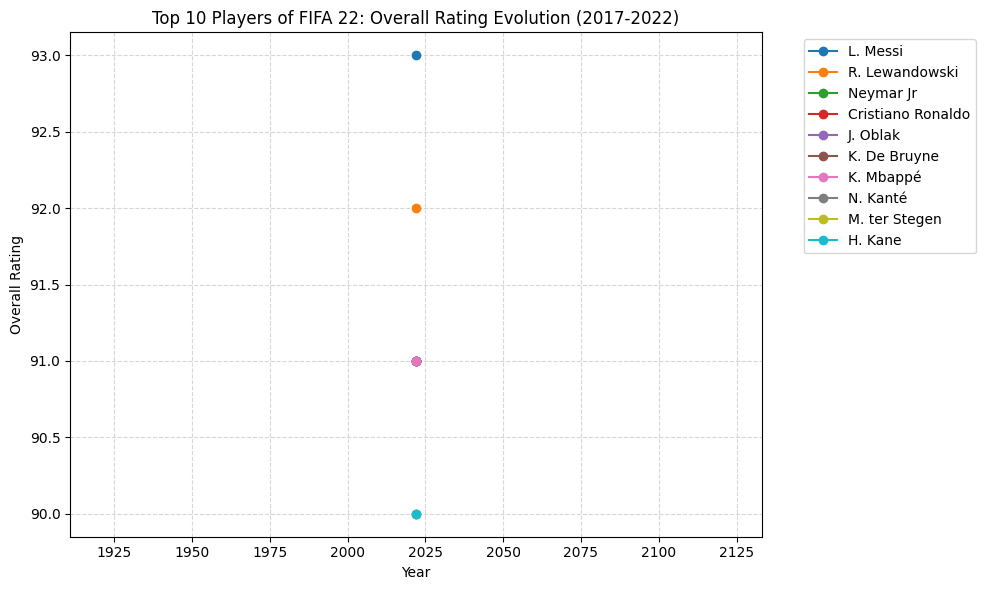

In [40]:
import matplotlib.pyplot as plt

# Plot Top 10 player trajectories
plt.figure(figsize=(10,6))
for player in top10_players_2022:
    player_data = top10_career_data[top10_career_data['Name'] == player]
    plt.plot(player_data['Year'], player_data['Overall'], marker='o', label=player)

plt.title('Top 10 Players of FIFA 22: Overall Rating Evolution (2017-2022)')
plt.xlabel('Year')
plt.ylabel('Overall Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

